# Simulating Archetypes

Here, we describe how to use the integrated simulator to generate data based on archetypes.

In [1]:
import partipy as pt
import scanpy as sc
import numpy as np

In [2]:
N_SAMPLES = 2_000
N_DIMENSION = 2
N_ARCHETYPES = 4
NOISE_STD = 0.10
SEED = 11

X, A, Z = pt.simulate_archetypes(n_samples=N_SAMPLES, n_archetypes=N_ARCHETYPES, n_dimensions=N_DIMENSION, noise_std=NOISE_STD, seed=SEED)
X, A, Z = X.astype(np.float32), A.astype(np.float32), Z.astype(np.float32)
adata = sc.AnnData(X=X.copy())
sc.pp.pca(adata, n_comps=N_DIMENSION, svd_solver="auto")

pt.set_obsm(adata=adata, obsm_key="X_pca", n_dimensions=2)

adata

AnnData object with n_obs × n_vars = 2000 × 2
    uns: 'pca', 'AA_config'
    obsm: 'X_pca'
    varm: 'PCs'

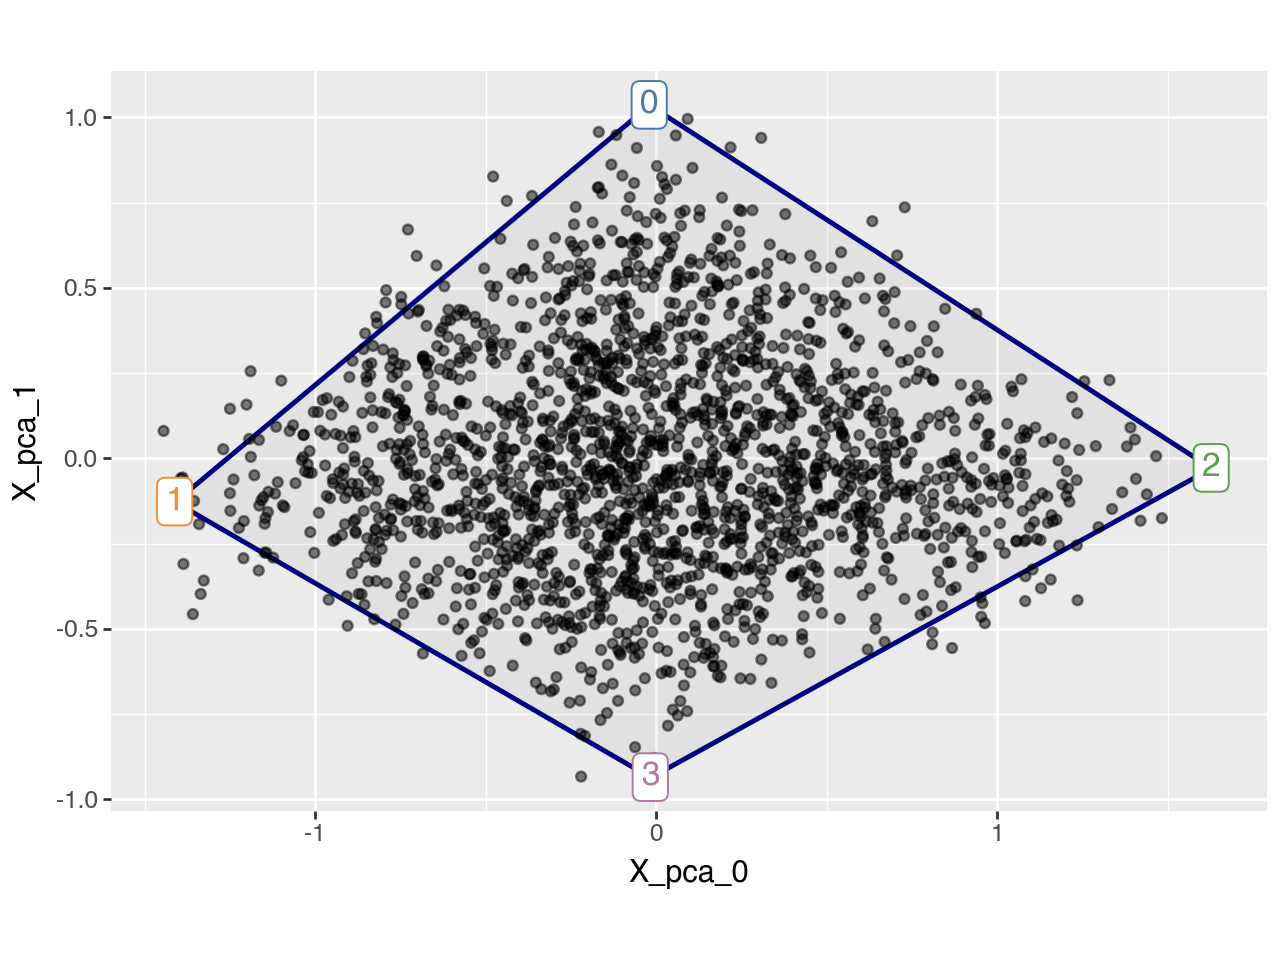

In [3]:
pt.compute_archetypes(adata, n_archetypes=N_ARCHETYPES, archetypes_only=False)
pt.plot_archetypes_2D(adata=adata)